# ENBIOS4TIMES: Environmental Assessment of Energy System Scenarios with ENBIOS

This notebook guides TIMES model users through the process of assessing the environmental impacts of their energy system scenarios using [**ENBIOS2**](https://github.com/LIVENlab/enbios)

**Workflow:**
1. What is ENBIOS?
2. Installation guide
3. Preparing the input folder (the basefile)
4. Soft-linking TIMES outputs to ENBIOS with Sparks
5. Running the Environmental Assessment
6. Visualizing Results


## 1. What is ENBIOS?

ENBIOS2 is a Python-based simulation tool for the socio-ecological assessment of energy system pathways.  It is designed to work with the outputs of Energy System Optimisation Models (ESOMs) such as TIMES.

This socio-ecological assessment has two blocks: i) the mapping and assessment of the life cycle inventories associated with technologies in the energy mix and ii) the upscaled assessment of the whole energy system. In doing so, it joins two system-related methodological approaches: life cycle assessment (LCA) and Multi-Scale Integrated Assessment of Socio-ecosystem Metabolism (MuSIASEM). In this way, both the improvements in design as well as the use and context of the technology can be considered in the calculations.

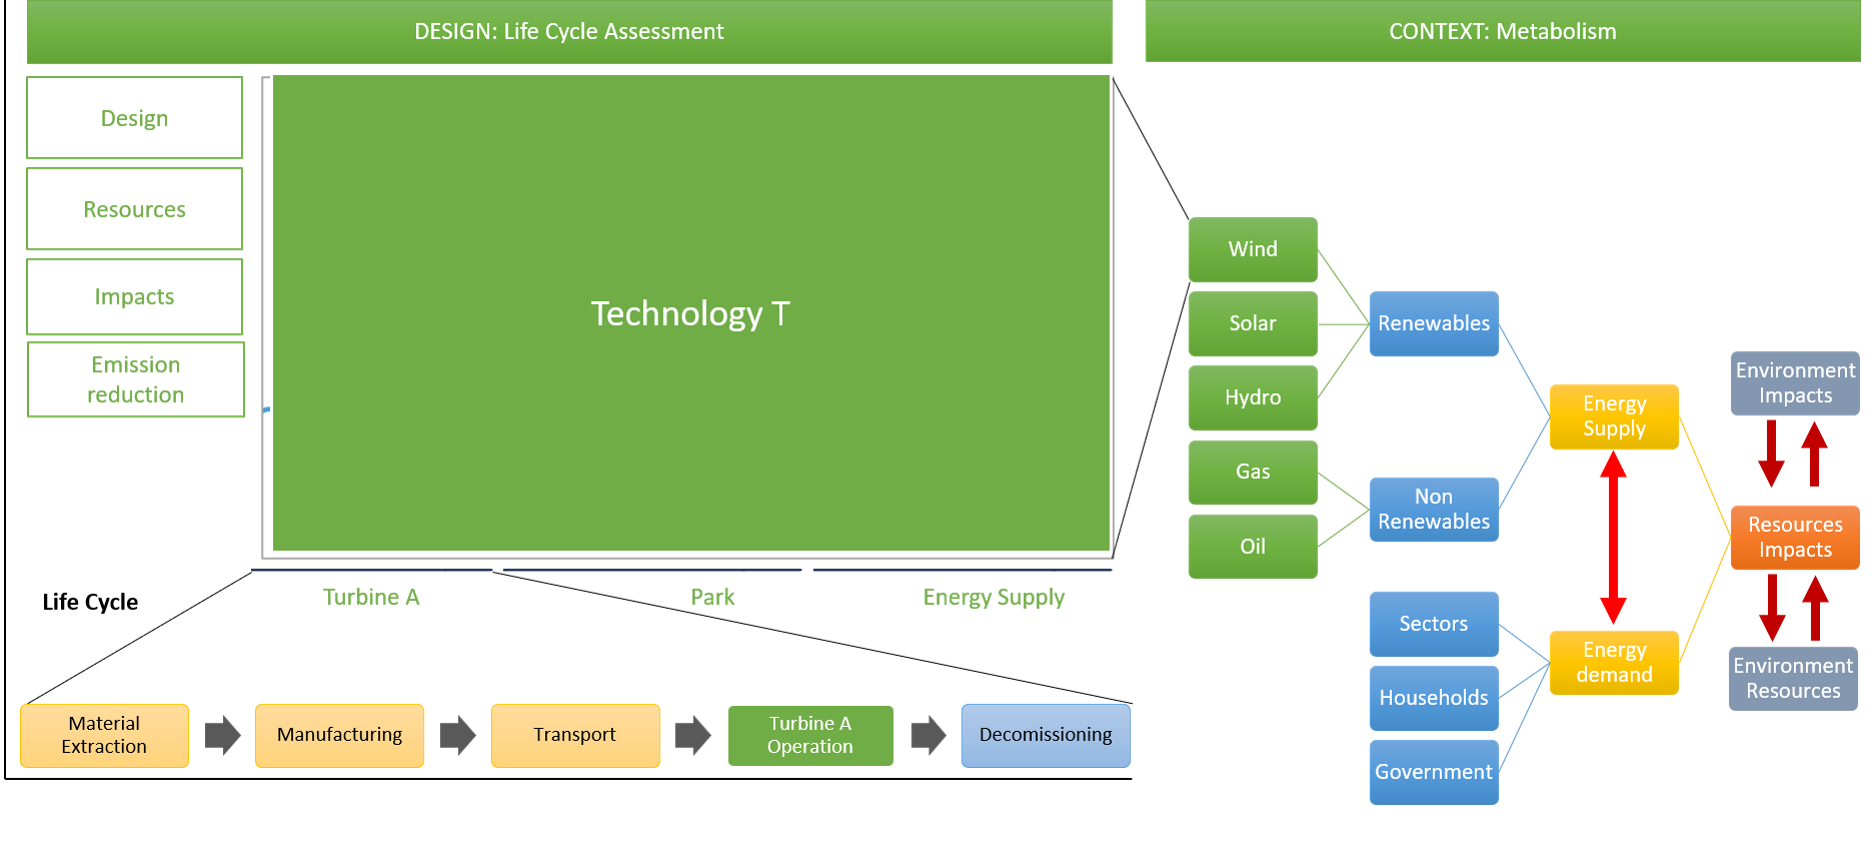


ENBIOS2 uses [Brightway2](https://docs.brightway.dev/) as its LCA engine and requires life cycle data that you can get from databases like [ecoinvent](https://ecoinvent.org/). The MuSIASEM part is formed by a set of functions that assess the social viability and environmental feasibility of the proposed energy system configuration. This is done by comparing the results of the system (or any level) with the limits of the socio-ecosystem, internal or external. Internal limits may be the amount of Lithium that can be extracted and processed whereas and external, environmental limit can be the amount of Lithium on earth.

You can see more information about ENBIOS2 here: https://github.com/LIVENlab/enbios

### How does it work?
You need to design a **hierarchy** structure (or **dendrogram**) of your energy configuration (or **scenario**) for the metabolism assessment in they way it is more convenient for your needs. Each **processor** (node) in this hierarchical diagram can relate to a function (activity that provides a service eg. production of cars) or a structure (the tangible part of functions, eg a factory), also depending on what you would like to study. Even though you can assess more than one **scenario**, the **dendrogram** is always the same.

The lower nodes of the **dendrogram** are always structures that can (and must) be mapped to a life cycle **inventory**. The assessment can be done using different **methods**. For the moment, a number of LCIA methods are included, but we are developing methods for the assessment of the geopolitical vulnerability, the impact distribution or the acceptance values.

To do this, we compile the hierarchical structure and the mapping to the inventories in **Experiments**, that can be run for one or many energy system **scenarios**.

#### Here are some key concepts

| Concept                         | Description                                                                                                                                |
|---------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------|
| **Experiment**                  | The top-level object that holds the hierarchy, adapters, methods and scenarios                                                             |
| **Hierarchy (dendrogram)**      | A tree structure of nodes representing the energy system                                                                                   |
| **Structural processor (leaf)** | An energy technology linked to a Brightway/ecoinvent activity                                                                              |
| **Functional processor**        | An aggregation node (e.g. wind energy, total electricity)                                                                                  |
| **Scenario**                    | A set of activity outputs representing one energy system pathway from TIMES                                                                |
| **Inventory**                   | A set of data that gives you information about the total material and energy inputs and outputs of an activity, considering its life cycle |
| **Method**                      | A method (e.g. LCA ReCiPe GWP1000) used to calculate environmental impacts                                                                 |


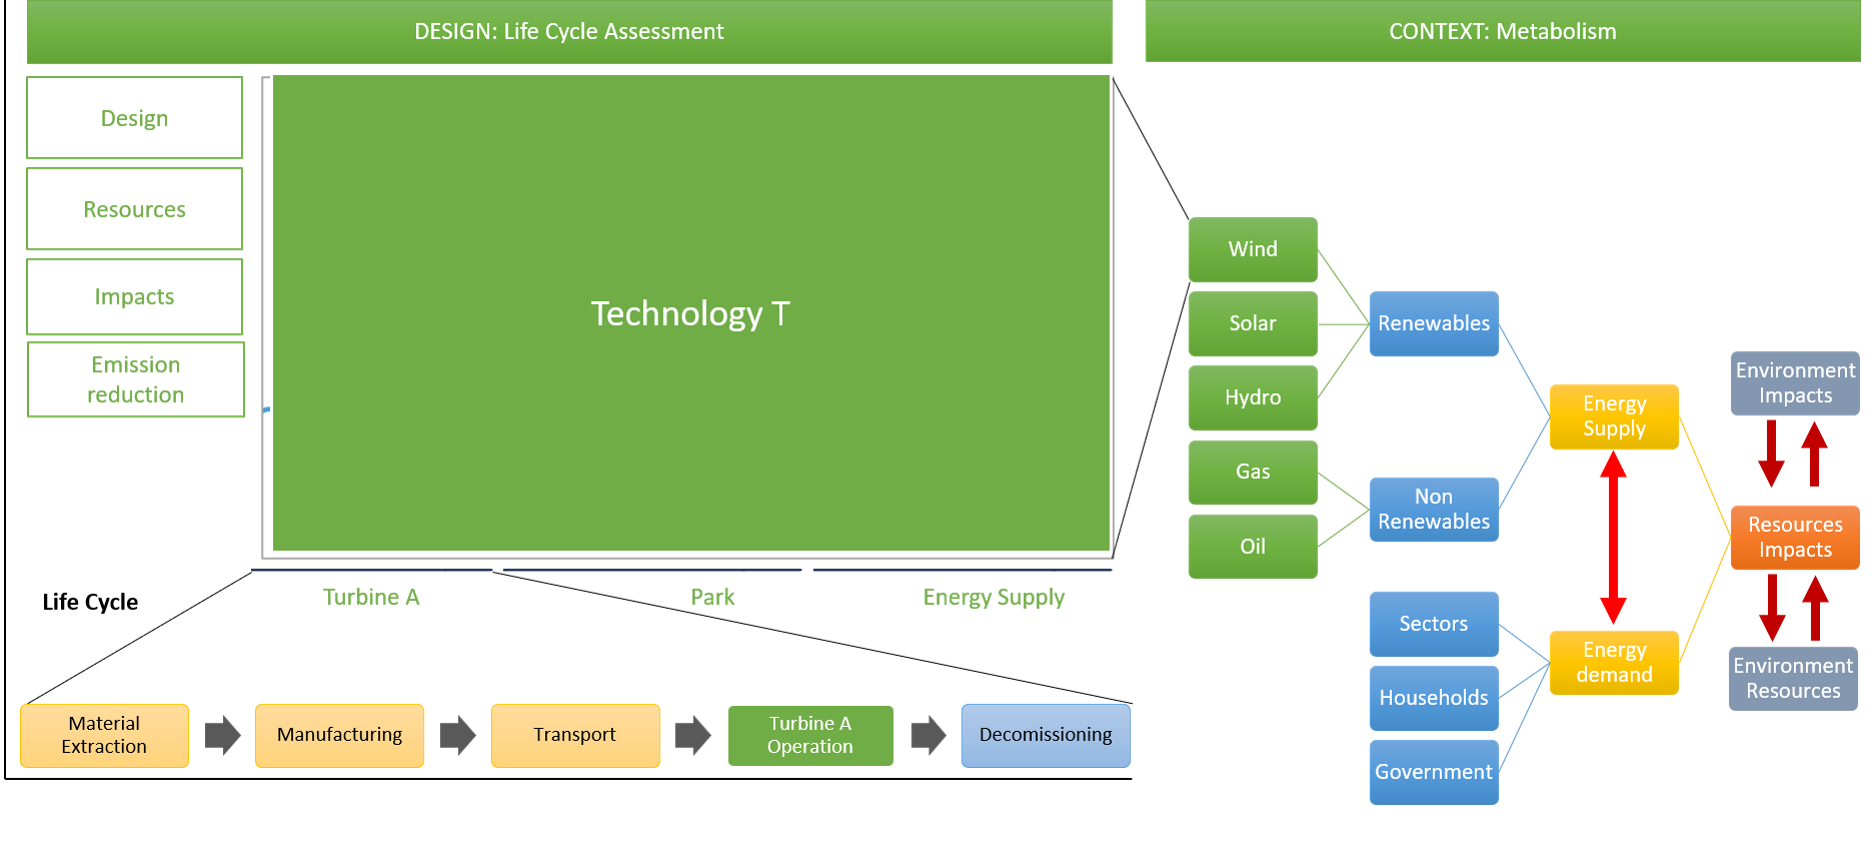

## 2. Installation and setup

ENBIOS2 currently works with python 3.10 Find it here: https://www.python.org/downloads/release/python-31011/

You can download the requirements_run.txt file to create your environment and be ready to work here: https://github.com/LIVENlab/enbios

If you need help creating your enviornment: https://www.jetbrains.com/help/pycharm/creating-virtual-environment.html#env-requirements

*PLEASE NOTE:  We are currently working on ENBIOS v2.3.14, adapted to python 14 and with new methods for assessment, stay tuned!*



## 3. ENBIOS inputs
ENBIOS takes the information from a JSON file that includes:
* your dendrogram
* the technology-life cycle inventory dictionary
* the results of your optimization (carriers produced and capacity installed, already connected with the dendrogram)
* The methods you want to use (and from which adapter. For LCA methods, you use brightway)
* A brightway project name where you have stored your inventory data (Ecoinvent or otherwise)

To make your life easier, you can  use [Sparks](https://github.com/LIVENlab/Sparks) to create the .JSON file from more human-readable sources:
* a basefile.xlsx where the dendrogram and the technology-life cycle inventory dictionary are defined
* a .csv file that contains your optimization output

As Sparks is not (yet!) a packaged/installable dependency, we have added its functions in this *Applications* folder for convenience.


### Inputs for SPARKS

#### Preparing the basefile

You can download a template of the basefile here: (#TODO)

In there you will find three sheets:

**`Processors`** - maps each TIMES technology to an ecoinvent activity:

| Column | Description |
|---|---|
| `Processor` | TIMES technology code, e.g. `EWIN1N` |
| `Region` | Region of the technology |
| `@SimulationCarrier` | TIMES energy carrier |
| `ParentProcessor` | Functional group this technology belongs to (must match a `Processor` in `Dendrogram_top`) |
| `@SimulationToEcoinventFactor` | Conversion factor from TIMES units to the ecoinvent activity's unit |
| `Ecoinvent_key_code` | ecoinvent activity code |
| `File_source` | Which energy-output file this technology's data comes from |
| `geo_loc` | ecoinvent activity location |

**`Methods`** - one row per method, as a `Formula` column holding a Python tuple literal, e.g.:
`"('ReCiPe 2016 v1.03, midpoint (H)', 'climate change', 'global warming potential (GWP1000)')"`
If you choose the brightway adapter, you can choose between a number of LCIA methods. But there is also the possibility to choose methods from a MuSIASEM adapter.

**`Dendrogram_top`** - the hierarchy above the technologies:

| Column | Description                                               |
|---|-----------------------------------------------------------|
| `Processor` | Node name (functional group or root)                      |
| `ParentProcessor` | Its parent node, that is a child node in the upper levels |
| `Level` | `n`, `n-1`, `n-2`, ... - depth from the leaves            |

### Your energy model output file(s)
CSV file that contains:
* a column with the same technology names that you have in the **Processors** sheet in the Basefile (Text)
* a column named like the file itself and which contains the capacity installed or the production of the technologies above (number)
* you may have other columns and that's fine.  Some examples:
     * a scenario number if you are doing analysis with MGA (what is MGA? Check out this work of  [Price and Keppo, 2017](https://www.sciencedirect.com/science/article/pii/S0306261917302957))
     * A region if you are running a regional assessment
     * A year/month if you are running temporal analysis

NOTE: Sparks will map inventories with technology names and then repeat as many times as rows with the same technology (and different year, region, or scenario) are in the file. You will be able to run the assessment for ENBIOS for all regions, years and scenarios you like (mind the computing capacity and time).


In [ ]:
import sys
from pathlib import Path

import bw2data
import pandas as pd

# Make the vendored Sparks_functions package importable (repo root = two levels above this notebook)
REPO_ROOT = Path.cwd().resolve().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from enbios import Experiment, report

# Check available Brightway projects and databases
report()

In [ ]:
# Set your Brightway project (must already exist)
PROJECT_NAME = "[your BW project]"

bw2data.projects.set_current(PROJECT_NAME)

## 3. Preparing the input folder (the basefile)

`SoftLink` takes a **folder path**, not individual file paths: it looks for a file named exactly `basefile.xlsx` inside that folder (required), and treats every other file in the same folder as candidate energy-output data.

### `basefile.xlsx` - required sheets

**`Processors`** - maps each TIMES technology to an ecoinvent activity:

| Column | Description |
|---|---|
| `Processor` | TIMES technology code, e.g. `EWIN1N` |
| `Region` | Region of the technology |
| `@SimulationCarrier` | TIMES energy carrier |
| `ParentProcessor` | Functional group this technology belongs to (must match a `Processor` in `Dendrogram_top`) |
| `@SimulationToEcoinventFactor` | Conversion factor from TIMES units to the ecoinvent activity's unit |
| `Ecoinvent_key_code` | ecoinvent activity code |
| `File_source` | Which energy-output file this technology's data comes from |
| `geo_loc` | ecoinvent activity location |

**`Methods`** - one row per LCIA method, as a `Formula` column holding a Python tuple literal, e.g.:
`"('ReCiPe 2016 v1.03, midpoint (H)', 'climate change', 'global warming potential (GWP1000)')"`

**`Dendrogram_top`** - the hierarchy above the technologies:

| Column | Description |
|---|---|
| `Processor` | Node name (functional group or root) |
| `ParentProcessor` | Its parent node |
| `Level` | `n`, `n-1`, `n-2`, ... - depth from the leaves |

### Energy output file(s)
CSV or Excel, with (after Sparks' internal cleaning) columns `full_name`, `energy_value`, `new_units`, `scenarios` - one row per technology, per scenario, per timestep.

## 4. Soft-linking TIMES outputs to ENBIOS with Sparks

Point `SoftLink` at the folder containing `basefile.xlsx` and your energy data, and your Brightway project.

In [ ]:
from Applications.Sparks_functions.util.base import SoftLink

# Folder containing basefile.xlsx + your TIMES/Calliope energy output file(s)
# Sample data bundled in this repo: "TIMES_input_data_sample" (relative to this notebook)
INPUT_FOLDER = r"[your path to the input folder]"

softlink = SoftLink(INPUT_FOLDER, PROJECT_NAME)

softlink.preprocess(national=False, specify_database=False)

Sparks will report technologies that are present in the energy data but missing from `basefile.xlsx` (or whose ecoinvent activity couldn't be found). Check them before continuing - anything listed here is silently excluded from the results:

In [ ]:
softlink.exluded_techs_and_regions

You can also check the preprocessed, unit-converted energy flows before they're turned into an ENBIOS hierarchy:

In [ ]:
softlink.preprocessed_units

Now build the ENBIOS-ready JSON (hierarchy, adapters/methods from the `Methods` sheet, and scenarios from the energy data) and save it:

In [ ]:
output_json = Path("data/enbios_input.json")
output_json.parent.mkdir(parents=True, exist_ok=True)

softlink.data_for_ENBIOS(smaller_vers=False, path_save=str(output_json))

In [ ]:
softlink.enbios2_data

If you want to check the structure of this file, you can use the following [JSON schema](https://github.com/LIVENlab/enbios/blob/main/data/schema/experiment.schema.gen.json) and a [validator](https://www.jsonschemavalidator.net/)

## 5. Running the Environmental Assessment

Now that Sparks has transformed the TIMES energy data into an ENBIOS-ready JSON, run the experiment.

In [ ]:
experiment = Experiment(str(output_json))
results = experiment.run()
print(f"Ran {len(results)} scenario(s) in {experiment.execution_time}")

Export the results to CSV and inspect them as a `DataFrame`:

In [ ]:
results_path = Path("results/ENBIOS_TIMES_results.csv")
results_path.parent.mkdir(parents=True, exist_ok=True)

experiment.results_to_csv(str(results_path))

df = pd.read_csv(results_path).fillna("")
df.head()

## 6. Visualizing Results

ENBIOS provides plotting helpers built on top of `ResultsSelector`, which wraps the experiment's results into a tidy `DataFrame` for plotting. Both take the `experiment` object directly:
- `bar_plot`: total impact per scenario, one subplot per LCIA method
- `stacked_bar_plot`: impact per scenario broken down by hierarchy level (e.g. `level=2` for technology groups)

In [ ]:
from enbios.base.result_select import ResultsSelector
from enbios.base.plot_experiment import bar_plot

rs = ResultsSelector.get_result_selector(experiment)
bar_plot(experiment)
rs.base_df

In [ ]:
from enbios.base.plot_experiment import stacked_bar_plot

stacked_bar_plot(experiment, level=2);

## 8. References and contact
This notebook is shared under a Creative Commons Attributional License: https://creativecommons.org/licenses/by/4.0/deed.en

To track issues with this notebook: https://github.com/LIVENlab/enbios/issues

If you want to test on other ESOM frameworks: cristina.madrid@ciemat.es

